# 12 — Failure-Case Analysis: ROI-Guided Attention

**Purpose.** This notebook performs a small, reproducible failure-case analysis for the main
two-class ROI-guided ResNet-50 experiment from Notebook 06.

It does **not train or fine-tune any model**. It reuses the saved:

- matched control model, \(\lambda=0\);
- validation-selected ROI-supervised model;
- validation-selected decision thresholds;
- locked-test predictions.

The analysis predefines two high-confidence failures of the **selected ROI-supervised model**:

1. one **false negative (FN)**: a malignant mammogram assigned the lowest malignant probability
   among selected-model false negatives;
2. one **false positive (FP)**: a non-malignant mammogram assigned the highest malignant probability
   among selected-model false positives.

Cases are selected algorithmically **before visual inspection**, reducing qualitative cherry-picking.

For each case the notebook reports:

- ground truth and predictions from both models;
- mammogram and radiologist true-class ROI;
- \(\lambda=0\) and ROI-supervised **true-class CAMs** for localisation;
- \(\lambda=0\) and ROI-supervised **decision-class CAMs** for explaining the actual prediction;
- case-level Pointing Game, pixel ROC-AUC, pixel average precision and Dice@0.5;
- ROI area fraction and available radiological descriptors (density, mass shape and margins).

> **Scientific framing:** the visualisations are a qualitative failure analysis, supported by
> quantitative per-case localisation measures. They do not establish a causal reason for an error.
> In the dissertation, distinguish (i) what is visibly observed, (ii) what published literature
> supports, and (iii) what is only a plausible interpretation.

In [2]:
import os
from pathlib import Path

print("CURRENT WORKING DIRECTORY:")
print(Path.cwd())

print("\nHOME:")
print(Path.home())

print("\nCOMMON LOCATIONS:")
locations = [
    "/content",
    "/content/drive",
    "/content/drive/MyDrive",
    "/content/gdrive_fresh",
    "/content/gdrive_fresh/MyDrive",
    "/scratch",
    "/home",
    "/mnt",
    "/mnt/data",
]

for p in locations:
    print(f"{p:35} exists={os.path.exists(p)}")
    if os.path.isdir(p):
        try:
            print("   first items:", os.listdir(p)[:20])
        except Exception as e:
            print("   cannot list:", e)

CURRENT WORKING DIRECTORY:
/content

HOME:
/root

COMMON LOCATIONS:
/content                            exists=True
   first items: ['.config', 'sample_data']
/content/drive                      exists=False
/content/drive/MyDrive              exists=False
/content/gdrive_fresh               exists=False
/content/gdrive_fresh/MyDrive       exists=False
/scratch                            exists=False
/home                               exists=True
   first items: []
/mnt                                exists=True
   first items: []
/mnt/data                           exists=False


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

print("Drive mounted:", os.path.exists("/content/drive"))
print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

if os.path.exists("/content/drive/MyDrive"):
    print(os.listdir("/content/drive/MyDrive")[:30])

Drive mounted: True
MyDrive exists: True
['Colab Notebooks', '15912168-1413-4694-ac47-94f007b4b8a9.jpg', '1bb999e0-7cdc-461c-b5b1-7274535dcb63.jpg', '42958274-a100-4029-84c8-87d18b063aed.jpg', '710e81f0-1694-4221-b085-64aaf0a4c953.jpg', 'IMG_3391.HEIC', 'IMG_3393.HEIC', 'IMG_3947.HEIC', 'IMG_3397.HEIC', 'IMG_3384.HEIC', 'IMG_3385.HEIC', 'IMG_3400.HEIC', 'IMG_3404.HEIC', 'IMG_3403.HEIC', 'IMG_3399.HEIC', 'IMG_3405.HEIC', 'IMG_3402.HEIC', 'IMG_3401.HEIC', 'IMG_3386.HEIC', 'IMG_3392.HEIC', 'IMG_3398.HEIC', 'IMG_6270.HEIC', 'IMG_6271.HEIC', 'IMG_6943.MOV', 'IMG_7457.MOV', 'IMG_6916.MOV', 'IMG_6862.MOV', 'IMG_6913.MOV', 'IMG_7460.MOV', 'IMG_6899.MOV']


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_dissertation"

print("Project exists:", os.path.exists(PROJECT_DIR))

if os.path.exists(PROJECT_DIR):
    print(os.listdir(PROJECT_DIR))

Project exists: True
['Results']


In [4]:
import os

RESULTS_DIR = "/content/drive/MyDrive/BreastCancer_dissertation/Results"

print("Results folders:")
for x in sorted(os.listdir(RESULTS_DIR)):
    print(x)

Results folders:
failure_case_analysis


In [5]:
ROI06_DIR = "/content/drive/MyDrive/BreastCancer_dissertation/Results/roi_attention_2class"

print("ROI06 exists:", os.path.exists(ROI06_DIR))

if os.path.exists(ROI06_DIR):
    print("\nNotebook 06 files:")
    for x in sorted(os.listdir(ROI06_DIR)):
        print(x)

ROI06 exists: False


In [6]:
import os

print("Searching for Notebook 06 outputs...\n")

targets = {
    "selected_lambda.json",
    "selected_thresholds.json",
    "test_pred_control_lambda0.csv",
    "test_pred_selected.csv",
    "resnet50_cam2_lambda0.0.pth",
    "resnet50_cam2_lambda0.5.pth",
}

found = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if f in targets:
            path = os.path.join(root, f)
            found.append(path)
            print(path)

print("\nTotal matching files found:", len(found))

Searching for Notebook 06 outputs...

/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Models/resnet50_cam2_lambda0.0.pth
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Models/resnet50_cam2_lambda0.5.pth
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/selected_lambda.json
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/selected_thresholds.json
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/test_pred_control_lambda0.csv
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention/test_pred_selected.csv
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/08_ConvNeXt_ROI/selected_lambda.json
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/08_ConvNeXt_ROI/

In [7]:
# 1. Set the correct mammogram dissertation project path
import os
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification"
)

ROI06_DIR = PROJECT_DIR / "Results" / "06_ROI_Attention"
MODEL_DIR = PROJECT_DIR / "Models"

SELECTED_JSON = ROI06_DIR / "selected_lambda.json"

# Safety checks
assert PROJECT_DIR.is_dir(), f"Project folder not found: {PROJECT_DIR}"
assert ROI06_DIR.is_dir(), f"Notebook 06 results folder not found: {ROI06_DIR}"
assert MODEL_DIR.is_dir(), f"Models folder not found: {MODEL_DIR}"
assert SELECTED_JSON.is_file(), f"selected_lambda.json not found: {SELECTED_JSON}"

print("✓ Project directory:", PROJECT_DIR)
print("✓ Notebook 06 results:", ROI06_DIR)
print("✓ Models directory:", MODEL_DIR)
print("✓ selected_lambda.json found")

print("\nNotebook 06 result files:")
for f in sorted(ROI06_DIR.iterdir()):
    print(" ", f.name)

✓ Project directory: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification
✓ Notebook 06 results: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention
✓ Models directory: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Models
✓ selected_lambda.json found

Notebook 06 result files:
  classification_test.csv
  config.json
  exact_split_assignments.csv
  localisation_per_case_control.csv
  localisation_per_case_selected.csv
  localisation_test.csv
  mask_coverage_by_split.csv
  paired_localisation_bootstrap.csv
  qualitative_panel.png
  relative_roi_area_stratification.csv
  selected_lambda.json
  selected_thresholds.json
  test_pred_control_lambda0.csv
  test_pred_selected.csv
  training_history.csv
  validation_by_lambda.csv
  validation_predictions_lambda0.0.csv
  validation_predictions_lambda0.1.csv
  validation_predictions_lambda0.5.csv
  validation_predictions_lambda1.0.csv


In [8]:
from pathlib import Path

DATA_DIR = PROJECT_DIR / "Data" / "CBIS-DDSM"
JPEG_DIR = DATA_DIR / "jpeg"

print("DATA_DIR exists:", DATA_DIR.exists())
print("JPEG_DIR exists:", JPEG_DIR.exists())

if DATA_DIR.exists():
    print("\nContents of DATA_DIR:")
    for x in sorted(DATA_DIR.iterdir()):
        print(" ", x.name)

print("\nRequired model checkpoints:")
for name in [
    "resnet50_cam2_lambda0.0.pth",
    "resnet50_cam2_lambda0.5.pth",
]:
    p = MODEL_DIR / name
    print(name, "->", p.exists())

DATA_DIR exists: True
JPEG_DIR exists: True

Contents of DATA_DIR:
  calc_case_description_test_set.csv
  calc_case_description_train_set.csv
  dicom_info.csv
  jpeg
  mass_case_description_test_set.csv
  mass_case_description_train_set.csv
  meta.csv

Required model checkpoints:
resnet50_cam2_lambda0.0.pth -> True
resnet50_cam2_lambda0.5.pth -> True


## 2. Imports, paths and prerequisite checks

In [10]:
import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.metrics import roc_auc_score, average_precision_score
from IPython.display import display

# ---------------------------------------------------------------------
# Paths — verified from completed Notebook 06
# ---------------------------------------------------------------------
PROJECT_DIR = "/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification"

DATA_DIR   = os.path.join(PROJECT_DIR, "Data", "CBIS-DDSM")
JPEG_DIR   = os.path.join(DATA_DIR, "jpeg")

# IMPORTANT: actual Notebook 06 results folder
ROI06_DIR  = os.path.join(PROJECT_DIR, "Results", "06_ROI_Attention")

MODEL_DIR  = os.path.join(PROJECT_DIR, "Models")

# Notebook 12 outputs are kept separate
OUTPUT_DIR = os.path.join(PROJECT_DIR, "Results", "12_Failure_Case_Analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_CSV = "mass_case_description_train_set.csv"
TEST_CSV  = "mass_case_description_test_set.csv"

SEED = 42
IMG_SIZE = 512
SUP_SIZE = 128
CROP_PAD_FRAC = 0.02
MASK_SIZE_TOL = 0.03
MASK_BINARY_MIN = 0.60

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


def require(path, label=None):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required Notebook-06 artifact not found:\n{path}\n\n"
            "The completed Notebook 06 outputs should already exist; "
            "do not retrain unless the original artefact is genuinely missing."
        )

    print("✓", label or os.path.basename(path))
    return path


# ---------------------------------------------------------------------
# Verify all required folders
# ---------------------------------------------------------------------
print("\nProject directory:", PROJECT_DIR)

assert os.path.isdir(PROJECT_DIR), f"Project directory missing: {PROJECT_DIR}"
assert os.path.isdir(DATA_DIR), f"CBIS-DDSM data directory missing: {DATA_DIR}"
assert os.path.isdir(JPEG_DIR), f"JPEG directory missing: {JPEG_DIR}"
assert os.path.isdir(MODEL_DIR), f"Model directory missing: {MODEL_DIR}"

print("\nChecking Notebook-06 output folder:")
print(ROI06_DIR)

if os.path.isdir(ROI06_DIR):
    print("\nFiles found in 06_ROI_Attention:")
    for _name in sorted(os.listdir(ROI06_DIR)):
        print("  ", _name)
else:
    raise FileNotFoundError(
        f"Notebook-06 results folder not found:\n{ROI06_DIR}"
    )


# ---------------------------------------------------------------------
# Notebook 06 saved artefacts
# ---------------------------------------------------------------------
SELECTED_JSON = require(
    os.path.join(ROI06_DIR, "selected_lambda.json"),
    "selected_lambda.json"
)

THRESH_JSON = require(
    os.path.join(ROI06_DIR, "selected_thresholds.json"),
    "selected_thresholds.json"
)

PRED_CONTROL = require(
    os.path.join(ROI06_DIR, "test_pred_control_lambda0.csv"),
    "control test predictions"
)

PRED_SELECTED = require(
    os.path.join(ROI06_DIR, "test_pred_selected.csv"),
    "selected-model test predictions"
)


# ---------------------------------------------------------------------
# Read selected λ and validation-selected thresholds
# ---------------------------------------------------------------------
with open(SELECTED_JSON, "r") as f:
    selection_info = json.load(f)

with open(THRESH_JSON, "r") as f:
    threshold_info = json.load(f)

selected_lambda = float(selection_info["selected_lambda"])
control_lambda = 0.0


# ---------------------------------------------------------------------
# Saved trained checkpoints — NO retraining
# ---------------------------------------------------------------------
CONTROL_CKPT = require(
    os.path.join(
        MODEL_DIR,
        f"resnet50_cam2_lambda{control_lambda}.pth"
    ),
    f"λ={control_lambda} checkpoint"
)

SELECTED_CKPT = require(
    os.path.join(
        MODEL_DIR,
        f"resnet50_cam2_lambda{selected_lambda}.pth"
    ),
    f"λ={selected_lambda} checkpoint"
)


threshold_control = float(
    threshold_info[str(control_lambda)]
)

threshold_selected = float(
    threshold_info[str(selected_lambda)]
)


# ---------------------------------------------------------------------
# Final audit
# ---------------------------------------------------------------------
print("\n---------------------------------------------")
print("Notebook 06 artefact audit PASSED")
print("---------------------------------------------")

print(f"Selected λ: {selected_lambda}")
print(
    f"Validation-selected threshold — control: "
    f"{threshold_control:.3f}"
)
print(
    f"Validation-selected threshold — selected: "
    f"{threshold_selected:.3f}"
)

print("\nFailure-analysis outputs will be saved to:")
print(OUTPUT_DIR)

print("\nNo training or fine-tuning will be performed in Notebook 12.")

Device: cuda

Project directory: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification

Checking Notebook-06 output folder:
/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/06_ROI_Attention

Files found in 06_ROI_Attention:
   classification_test.csv
   config.json
   exact_split_assignments.csv
   localisation_per_case_control.csv
   localisation_per_case_selected.csv
   localisation_test.csv
   mask_coverage_by_split.csv
   paired_localisation_bootstrap.csv
   qualitative_panel.png
   relative_roi_area_stratification.csv
   selected_lambda.json
   selected_thresholds.json
   test_pred_control_lambda0.csv
   test_pred_selected.csv
   training_history.csv
   validation_by_lambda.csv
   validation_predictions_lambda0.0.csv
   validation_predictions_lambda0.1.csv
   validation_predictions_lambda0.5.csv
   validation_predictions_lambda1.0.csv
✓ selected_lambda.json
✓ selected_thresholds.json
✓ control test predictions
✓ selected

## 3. Reconstruct the locked CBIS-DDSM test metadata

This uses the same image-level aggregation rule as Notebook 06:

- one sample per patient–breast–view;
- an image is labelled malignant if **any** abnormality on that mammogram is malignant;
- benign and malignant ROI paths are kept separately;
- mixed-pathology mammograms are therefore malignant, and the malignant ROI is the true-class ROI.

Only the locked official test set is used for case selection.

In [11]:
ALLOWED = {"BENIGN", "BENIGN_WITHOUT_CALLBACK", "MALIGNANT"}

def find_csv(name):
    for candidate in (os.path.join(DATA_DIR, name), os.path.join(DATA_DIR, "csv", name)):
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError(name)

def uid_from(p):
    return str(p).split("/")[-2]

def jpegs_from(mp):
    folder = os.path.join(JPEG_DIR, uid_from(mp))
    if not os.path.isdir(folder):
        return []
    return [
        os.path.join(folder, f)
        for f in sorted(os.listdir(folder))
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

def first_jpeg(mp):
    fs = jpegs_from(mp)
    return fs[0] if fs else None

def join_unique(values):
    out = []
    for x in values:
        if isinstance(x, str) and x and x not in out:
            out.append(x)
    return "||".join(out)

def build_df(case_csv):
    raw = pd.read_csv(find_csv(case_csv))
    observed = set(raw["pathology"].dropna().astype(str).str.upper())
    assert observed.issubset(ALLOWED), f"Unexpected pathology values: {observed - ALLOWED}"

    raw["is_malignant_abn"] = (
        raw["pathology"].astype(str).str.upper() == "MALIGNANT"
    )
    raw["full_jpeg"] = raw["image file path"].apply(first_jpeg)

    raw["roi_b"] = np.where(
        ~raw["is_malignant_abn"], raw["ROI mask file path"], None
    )
    raw["roi_m"] = np.where(
        raw["is_malignant_abn"], raw["ROI mask file path"], None
    )

    df = (
        raw.dropna(subset=["full_jpeg"])
        .groupby(
            ["patient_id", "left or right breast", "image view"],
            as_index=False
        )
        .agg(
            full_jpeg=("full_jpeg", "first"),
            label=("is_malignant_abn", "max"),
            n_abn=("is_malignant_abn", "size"),
            n_malignant_abn=("is_malignant_abn", "sum"),
            benign_roi=("roi_b", join_unique),
            malignant_roi=("roi_m", join_unique),
            breast_density=("breast_density", "first"),
            mass_shape=("mass shape", lambda x: "; ".join(sorted(set(map(str, x))))),
            mass_margins=("mass margins", lambda x: "; ".join(sorted(set(map(str, x))))),
        )
    )

    df["label"] = df["label"].astype(int)
    df["mixed_pathology"] = (
        (df["n_malignant_abn"] > 0) &
        (df["n_malignant_abn"] < df["n_abn"])
    ).astype(int)

    df["sample_id"] = (
        df["patient_id"].astype(str) + "|" +
        df["left or right breast"].astype(str) + "|" +
        df["image view"].astype(str)
    )
    return df.reset_index(drop=True)

test_df = build_df(TEST_CSV)
print(
    f"Locked official test set: {len(test_df)} mammograms, "
    f"{test_df.patient_id.nunique()} patients"
)

pred_control = pd.read_csv(PRED_CONTROL)
pred_selected = pd.read_csv(PRED_SELECTED)

required_pred_cols = {"sample_id", "patient_id", "y_true", "p_malignant"}
assert required_pred_cols.issubset(pred_control.columns)
assert required_pred_cols.issubset(pred_selected.columns)
assert len(pred_control) == len(test_df) == len(pred_selected)
assert set(pred_control.sample_id) == set(test_df.sample_id) == set(pred_selected.sample_id)

_check = pred_selected[["sample_id", "y_true"]].merge(
    test_df[["sample_id", "label"]], on="sample_id", how="inner"
)
assert (_check["y_true"].astype(int) == _check["label"].astype(int)).all(), \
    "Prediction labels do not match reconstructed locked-test labels."

print("✓ Prediction files match the reconstructed locked test set.")

Locked official test set: 361 mammograms, 201 patients
✓ Prediction files match the reconstructed locked test set.


## 4. Exact Notebook-06 breast preprocessing and ROI registration

In [12]:
def load_gray(path):
    return np.array(Image.open(path).convert("L"), dtype=np.uint8)

def otsu(g):
    h = np.bincount(g.ravel(), minlength=256).astype(float)
    p = h / max(g.size, 1)
    om = np.cumsum(p)
    mu = np.cumsum(p * np.arange(256))
    mt = mu[-1]
    s = (mt * om - mu) ** 2 / np.maximum(om * (1 - om), 1e-12)
    s[(om <= 0) | (om >= 1)] = 0
    return int(np.argmax(s))

def bbox(g, pad=CROP_PAD_FRAC):
    h, w = g.shape
    m = g > max(otsu(g), 5)
    m = ndimage.binary_opening(m, structure=np.ones((3,3)))
    m = ndimage.binary_closing(m, structure=np.ones((7,7)))
    lab, n = ndimage.label(m)
    if n == 0:
        return (0, 0, w, h)

    counts = np.bincount(lab.ravel())
    counts[0] = 0
    ys, xs = np.where(lab == counts.argmax())
    if len(xs) == 0:
        return (0, 0, w, h)

    q = int(round(pad * max(h, w)))
    return (
        max(int(xs.min()) - q, 0),
        max(int(ys.min()) - q, 0),
        min(int(xs.max()) + 1 + q, w),
        min(int(ys.max()) + 1 + q, h),
    )

def _crop_pad_resize(a, bb, resample):
    left, top, right, bottom = bb
    cropped = Image.fromarray(a).crop((left, top, right, bottom))
    cw, ch = cropped.size
    side = max(cw, ch)
    canvas = Image.new("L", (side, side), 0)
    canvas.paste(cropped, ((side - cw)//2, (side - ch)//2))
    return np.array(canvas.resize((IMG_SIZE, IMG_SIZE), resample))

def crop_img(g, bb):
    return _crop_pad_resize(g, bb, Image.BILINEAR).astype(np.uint8)

def crop_mask(m, bb):
    return (_crop_pad_resize(m, bb, Image.NEAREST) > 127).astype(np.uint8)

def register_masks(roi_field, shape, tol=MASK_SIZE_TOL, binary_min=MASK_BINARY_MIN):
    fh, fw = shape
    union = np.zeros((fh, fw), np.uint8)
    found = False

    for mask_path in str(roi_field).split("||"):
        if not mask_path or mask_path == "nan":
            continue

        for f in jpegs_from(mask_path):
            a = load_gray(f)
            h, w = a.shape

            if abs(h-fh)/max(fh,1) > tol or abs(w-fw)/max(fw,1) > tol:
                continue

            if float(np.mean((a < 20) | (a > 235))) < binary_min:
                continue

            if (h, w) != (fh, fw):
                a = np.array(
                    Image.fromarray(a).resize((fw, fh), Image.NEAREST)
                )

            m = a > 127
            if m.mean() > 0.5:
                m = ~m

            m = m.astype(np.uint8)
            if m.sum() == 0:
                continue

            union = np.maximum(union, m)
            found = True

    return union if (found and union.sum() > 0) else None

def prepare_case(row):
    # Create the exact 512x512 breast image and true-class ROI mask used for analysis.
    g = load_gray(row.full_jpeg)
    bb = bbox(g)
    image512 = crop_img(g, bb)

    roi_field = row.malignant_roi if int(row.label) == 1 else row.benign_roi
    full_mask = register_masks(roi_field, g.shape)

    if full_mask is None:
        return None

    mask512 = crop_mask(full_mask * 255, bb)
    if mask512.sum() == 0:
        return None

    return {
        "image512": image512,
        "mask512": mask512.astype(bool),
        "bbox": bb,
    }

## 5. Deterministic failure-case selection

The default rule selects the **highest-confidence errors** made by the selected ROI-supervised
model:

- FN: smallest \(p(\mathrm{malignant})\) among malignant cases predicted non-malignant;
- FP: largest \(p(\mathrm{malignant})\) among non-malignant cases predicted malignant.

A candidate is accepted only if its true-class radiologist ROI can be reconstructed with the same
registration rules as Notebook 06.

This rule is fixed before viewing the images. It is therefore reproducible and does not select cases
because their attention maps happen to look favourable.

In [13]:
merged = (
    pred_selected.rename(columns={"p_malignant": "p_selected"})
    .merge(
        pred_control[["sample_id", "p_malignant"]].rename(
            columns={"p_malignant": "p_control"}
        ),
        on="sample_id",
        how="inner",
    )
    .merge(test_df, on="sample_id", how="inner", suffixes=("", "_meta"))
)

assert (merged["y_true"].astype(int) == merged["label"].astype(int)).all()

merged["pred_selected"] = (merged["p_selected"] >= threshold_selected).astype(int)
merged["pred_control"]  = (merged["p_control"] >= threshold_control).astype(int)

fn_candidates = merged[
    (merged["label"] == 1) & (merged["pred_selected"] == 0)
].sort_values(["p_selected", "sample_id"], ascending=[True, True])

fp_candidates = merged[
    (merged["label"] == 0) & (merged["pred_selected"] == 1)
].sort_values(["p_selected", "sample_id"], ascending=[False, True])

print("Selected-model errors on locked test:")
print("  False negatives:", len(fn_candidates))
print("  False positives:", len(fp_candidates))

assert len(fn_candidates) > 0, "No selected-model false negatives found."
assert len(fp_candidates) > 0, "No selected-model false positives found."

def first_valid(candidates, case_type):
    for _, row in candidates.iterrows():
        prepared = prepare_case(row)
        if prepared is not None:
            return row.copy(), prepared
    raise RuntimeError(f"No {case_type} candidate had a reconstructable true-class ROI.")

fn_row, fn_data = first_valid(fn_candidates, "false-negative")
fp_row, fp_data = first_valid(fp_candidates, "false-positive")

cases = {
    "False negative": (fn_row, fn_data),
    "False positive": (fp_row, fp_data),
}

print("\nPredefined failure cases:")
for name, (r, _) in cases.items():
    gt = "malignant" if int(r.label) == 1 else "non-malignant"
    ps = "malignant" if int(r.pred_selected) == 1 else "non-malignant"
    print(
        f"{name}: {r.sample_id} | GT={gt} | selected prediction={ps} | "
        f"p_malignant={r.p_selected:.4f}"
    )

Selected-model errors on locked test:
  False negatives: 23
  False positives: 108

Predefined failure cases:
False negative: P_00932|LEFT|MLO | GT=malignant | selected prediction=non-malignant | p_malignant=0.0727
False positive: P_00490|RIGHT|CC | GT=non-malignant | selected prediction=malignant | p_malignant=0.9915


## 6. Load the matched control and ROI-supervised models

In [14]:
class ResNetCAM2(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        # weights=None avoids any network download; Notebook-06 checkpoints contain all weights.
        bb = models.resnet50(weights=None)
        self.features = nn.Sequential(
            bb.conv1, bb.bn1, bb.relu, bb.maxpool,
            bb.layer1, bb.layer2, bb.layer3, bb.layer4
        )
        self.cam_conv = nn.Conv2d(2048, n_classes, 1)

    def forward(self, x, return_cam=False):
        f = self.features(x)
        cam = self.cam_conv(f)
        logits = F.adaptive_avg_pool2d(cam, 1).flatten(1)
        return (logits, cam) if return_cam else logits

def load_model(path):
    m = ResNetCAM2().to(device)
    state = torch.load(path, map_location=device)
    m.load_state_dict(state)
    m.eval()
    return m

control_model = load_model(CONTROL_CKPT)
selected_model = load_model(SELECTED_CKPT)

print("✓ Both Notebook-06 models loaded; no training performed.")

✓ Both Notebook-06 models loaded; no training performed.


## 7. CAMs and case-level localisation metrics

For each error, two distinct views are useful:

- **True-class CAM:** evaluates whether evidence for the actual class is spatially aligned with the
  radiologist ROI. This is consistent with Notebook 06's localisation protocol.
- **Decision-class CAM:** visualises evidence for the class actually predicted by that model. For a
  misclassified case, this helps inspect the spatial basis of the incorrect decision.

Do not confuse the two in the report.

In [15]:
def to_tensor(image512):
    arr = image512.astype(np.float32) / 255.0
    t = torch.from_numpy(np.stack([arr, arr, arr], axis=0))
    return ((t - MEAN) / STD).float()

@torch.no_grad()
def probability_and_cam(model, image512, class_index, size=SUP_SIZE):
    t = to_tensor(image512).unsqueeze(0).to(device)
    logits, cams = model(t, return_cam=True)
    prob = torch.softmax(logits, dim=1)[0, 1].item()

    c = F.interpolate(
        cams[:, class_index:class_index+1],
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    ).squeeze().detach().cpu().numpy()

    c = c - c.min()
    if c.max() > 0:
        c = c / c.max()

    return float(prob), c

def resize_mask(mask512, size=SUP_SIZE):
    return np.array(
        Image.fromarray((mask512.astype(np.uint8) * 255))
        .resize((size, size), Image.NEAREST)
    ) > 127

def localisation_metrics(cam, mask):
    mask = mask.astype(bool)
    assert mask.sum() > 0

    peak = np.unravel_index(np.argmax(cam), cam.shape)
    pointing_game = int(mask[peak])

    if 0 < mask.sum() < mask.size:
        pixel_auc = float(roc_auc_score(mask.ravel(), cam.ravel()))
        pixel_ap = float(average_precision_score(mask.ravel(), cam.ravel()))
    else:
        pixel_auc = np.nan
        pixel_ap = np.nan

    pred_mask = cam >= 0.5
    inter = np.logical_and(pred_mask, mask).sum()
    denom = pred_mask.sum() + mask.sum()
    dice = float(2 * inter / denom) if denom else 0.0

    return {
        "pointing_game": pointing_game,
        "pixel_auc": pixel_auc,
        "pixel_ap": pixel_ap,
        "dice@0.5": dice,
    }

analysis = {}
metric_rows = []

for case_name, (r, prepared) in cases.items():
    image512 = prepared["image512"]
    mask128 = resize_mask(prepared["mask512"])

    true_class = int(r.label)
    control_pred_class = int(r.pred_control)
    selected_pred_class = int(r.pred_selected)

    p_c, cam_c_true = probability_and_cam(control_model, image512, true_class)
    p_s, cam_s_true = probability_and_cam(selected_model, image512, true_class)
    _, cam_c_decision = probability_and_cam(control_model, image512, control_pred_class)
    _, cam_s_decision = probability_and_cam(selected_model, image512, selected_pred_class)

    assert np.isclose(p_c, float(r.p_control), atol=2e-4), \
        f"Control probability mismatch for {r.sample_id}: {p_c} vs {r.p_control}"
    assert np.isclose(p_s, float(r.p_selected), atol=2e-4), \
        f"Selected probability mismatch for {r.sample_id}: {p_s} vs {r.p_selected}"

    m_c = localisation_metrics(cam_c_true, mask128)
    m_s = localisation_metrics(cam_s_true, mask128)

    for model_name, mm in [("control_lambda0", m_c), ("roi_supervised", m_s)]:
        metric_rows.append({
            "case": case_name,
            "sample_id": r.sample_id,
            "model": model_name,
            "true_class": true_class,
            **mm,
        })

    analysis[case_name] = {
        "row": r,
        "image512": image512,
        "mask128": mask128,
        "control_true_cam": cam_c_true,
        "selected_true_cam": cam_s_true,
        "control_decision_cam": cam_c_decision,
        "selected_decision_cam": cam_s_decision,
        "metrics_control": m_c,
        "metrics_selected": m_s,
    }

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))
metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "failure_case_localisation_metrics.csv"),
    index=False
)

,case,sample_id,model,true_class,pointing_game,pixel_auc,pixel_ap,dice@0.5
0,False negative,P_00932|LEFT|MLO,control_lambda0,1,0,0.9365,0.0106,0.0042
1,False negative,P_00932|LEFT|MLO,roi_supervised,1,0,0.9689,0.0212,0.0029
2,False positive,P_00490|RIGHT|CC,control_lambda0,0,0,0.2201,0.0011,0.0037
3,False positive,P_00490|RIGHT|CC,roi_supervised,0,0,0.9384,0.0127,0.0035


## 8. Report-ready case summary

In [16]:
def class_name(v):
    return "malignant" if int(v) == 1 else "non-malignant"

summary_rows = []

for case_name, item in analysis.items():
    r = item["row"]
    roi_fraction = float(item["mask128"].mean())

    summary_rows.append({
        "case": case_name,
        "sample_id": r.sample_id,
        "patient_id": str(r.patient_id),
        "laterality": r["left or right breast"],
        "view": r["image view"],
        "ground_truth": class_name(r.label),

        "control_prediction": class_name(r.pred_control),
        "control_p_malignant": float(r.p_control),
        "control_threshold": threshold_control,

        "selected_prediction": class_name(r.pred_selected),
        "selected_p_malignant": float(r.p_selected),
        "selected_threshold": threshold_selected,

        "roi_area_fraction_128": roi_fraction,
        "breast_density": r.breast_density,
        "mass_shape": r.mass_shape,
        "mass_margins": r.mass_margins,
        "mixed_pathology": int(r.mixed_pathology),

        "control_trueclass_pointing_game": item["metrics_control"]["pointing_game"],
        "selected_trueclass_pointing_game": item["metrics_selected"]["pointing_game"],
        "control_trueclass_pixel_ap": item["metrics_control"]["pixel_ap"],
        "selected_trueclass_pixel_ap": item["metrics_selected"]["pixel_ap"],
        "control_trueclass_pixel_auc": item["metrics_control"]["pixel_auc"],
        "selected_trueclass_pixel_auc": item["metrics_selected"]["pixel_auc"],
        "control_trueclass_dice": item["metrics_control"]["dice@0.5"],
        "selected_trueclass_dice": item["metrics_selected"]["dice@0.5"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.T)

summary_path = os.path.join(OUTPUT_DIR, "failure_case_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)

,0,1
case,False negative,False positive
sample_id,P_00932|LEFT|MLO,P_00490|RIGHT|CC
patient_id,P_00932,P_00490
laterality,LEFT,RIGHT
view,MLO,CC
ground_truth,malignant,non-malignant
control_prediction,non-malignant,malignant
control_p_malignant,0.1533,0.963016
control_threshold,0.44,0.44
selected_prediction,non-malignant,malignant


Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/12_Failure_Case_Analysis/failure_case_summary.csv


## 9. Report-ready visualisations

Each row is one predefined selected-model error.

Columns:

1. breast-focused mammogram with radiologist **true-class ROI** contour;
2. control \(\lambda=0\) **true-class CAM**;
3. selected ROI-supervised **true-class CAM**;
4. control **decision-class CAM**;
5. selected ROI-supervised **decision-class CAM**.

The true-class panels address spatial localisation. The decision-class panels address the evidence
associated with the model's actual prediction.

The figure is also saved as two individual case figures so the dissertation can use either a compact
combined panel or larger separate figures.

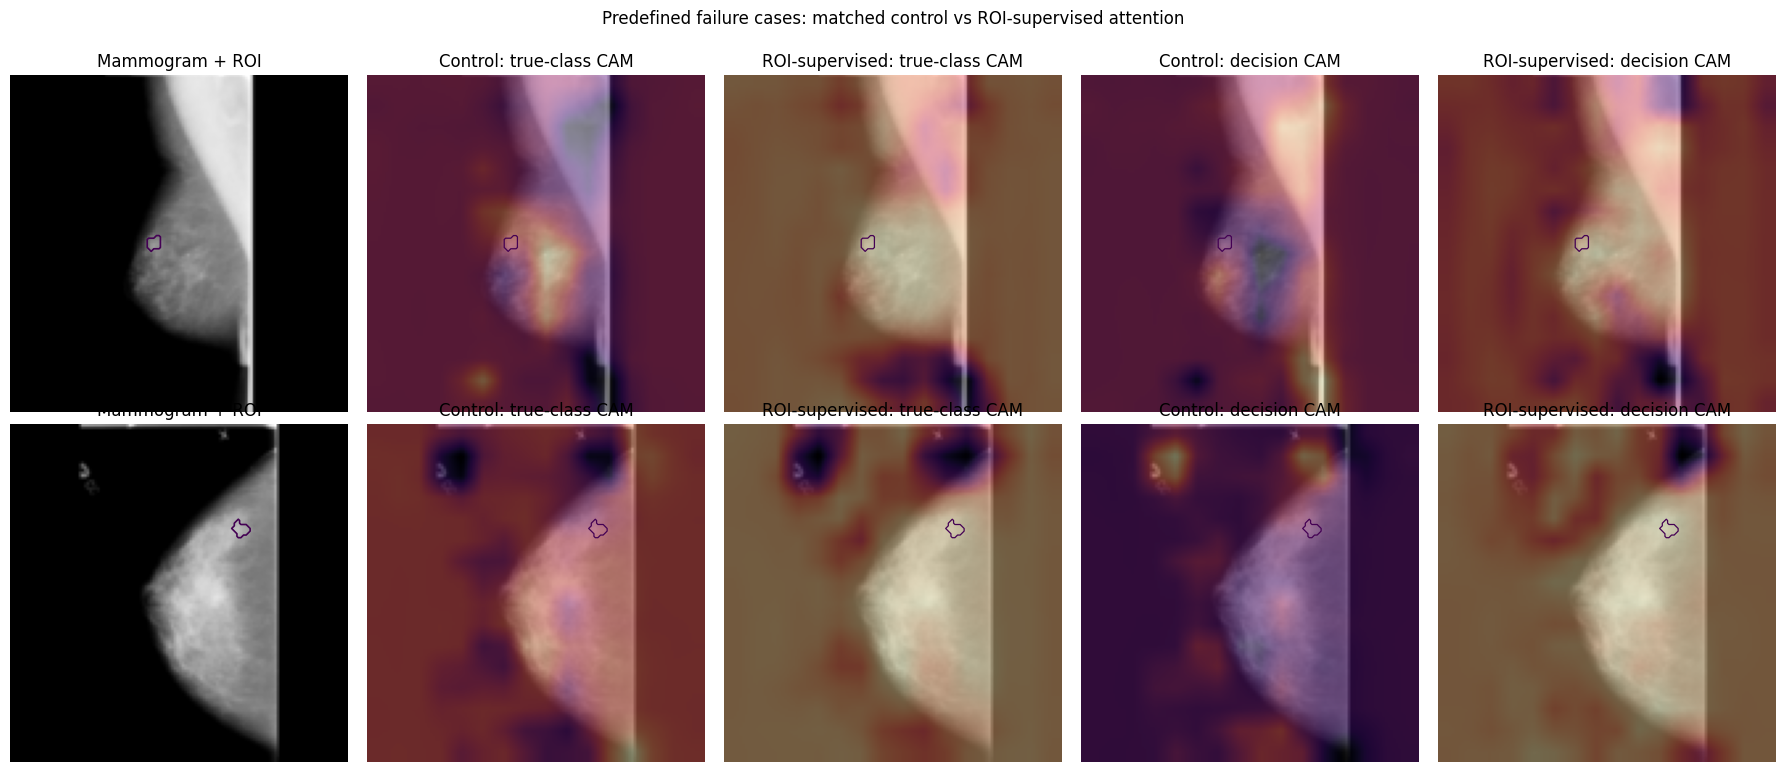

Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/12_Failure_Case_Analysis/failure_case_panel.png


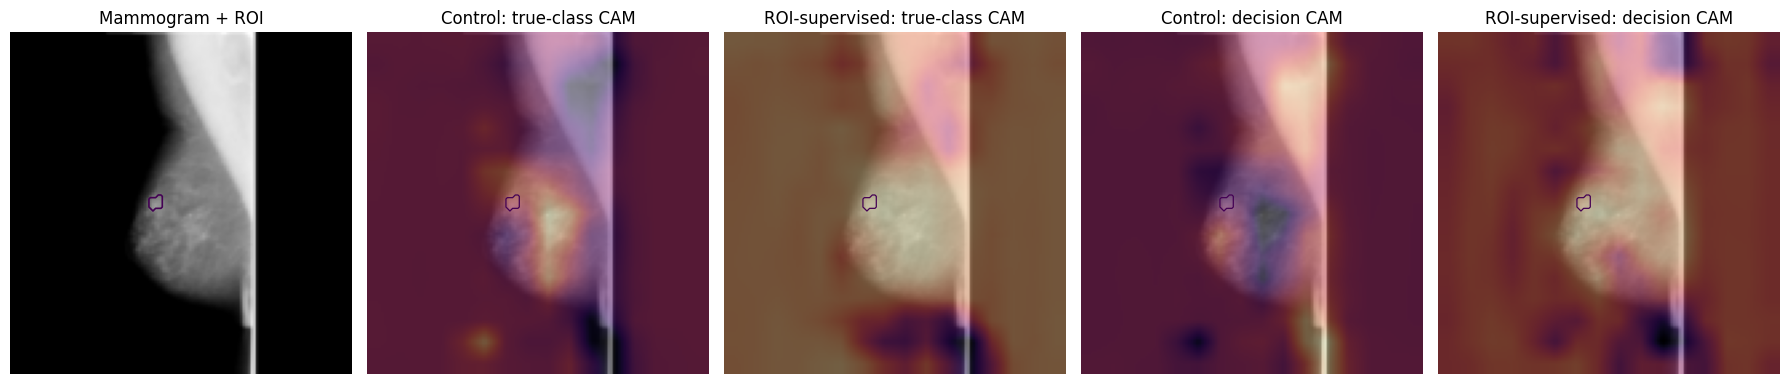

Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/12_Failure_Case_Analysis/false_negative_attention_panel.png


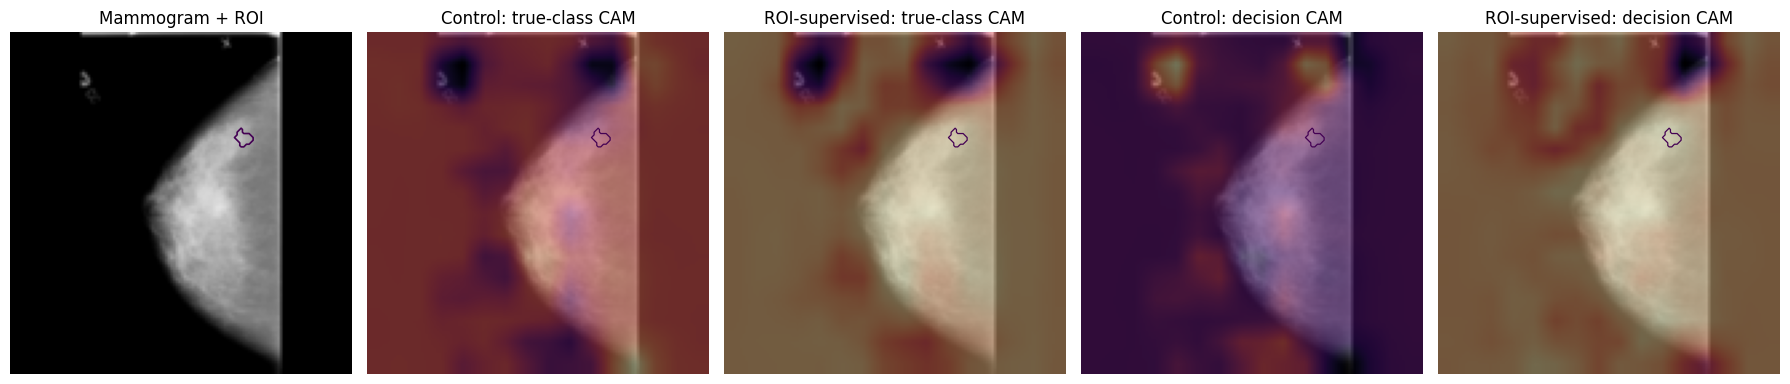

Saved: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/12_Failure_Case_Analysis/false_positive_attention_panel.png


In [17]:
def normalise_gray_for_display(image512):
    img = Image.fromarray(image512).resize((SUP_SIZE, SUP_SIZE), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

def overlay_cam(gray01, cam):
    base = np.dstack([gray01, gray01, gray01])
    heat = matplotlib.colormaps["magma"](cam)[..., :3]
    return np.clip(0.55 * base + 0.45 * heat, 0, 1)

def draw_case_row(ax_row, case_name, item):
    r = item["row"]
    gray = normalise_gray_for_display(item["image512"])
    mask = item["mask128"]

    ax_row[0].imshow(gray, cmap="gray")
    ax_row[0].contour(mask.astype(float), levels=[0.5], linewidths=1.2)
    ax_row[0].set_title("Mammogram + ROI")

    panels = [
        ("Control: true-class CAM", item["control_true_cam"]),
        ("ROI-supervised: true-class CAM", item["selected_true_cam"]),
        ("Control: decision CAM", item["control_decision_cam"]),
        ("ROI-supervised: decision CAM", item["selected_decision_cam"]),
    ]

    for ax, (title, cam) in zip(ax_row[1:], panels):
        ax.imshow(overlay_cam(gray, cam))
        ax.contour(mask.astype(float), levels=[0.5], linewidths=0.9)
        ax.set_title(title)

    for ax in ax_row:
        ax.axis("off")

    gt = class_name(r.label)
    cp = class_name(r.pred_control)
    sp = class_name(r.pred_selected)

    ax_row[0].set_ylabel(
        f"{case_name}\n"
        f"GT: {gt}\n"
        f"Control: {cp}, p={r.p_control:.3f}\n"
        f"Selected: {sp}, p={r.p_selected:.3f}",
        rotation=0,
        ha="right",
        va="center",
        labelpad=10,
    )

case_names = list(analysis.keys())
fig, axes = plt.subplots(
    len(case_names), 5,
    figsize=(18, 3.8 * len(case_names)),
    squeeze=False
)

for row_idx, case_name in enumerate(case_names):
    draw_case_row(axes[row_idx], case_name, analysis[case_name])

fig.suptitle(
    "Predefined failure cases: matched control vs ROI-supervised attention",
    y=1.01
)
fig.tight_layout()

combined_path = os.path.join(OUTPUT_DIR, "failure_case_panel.png")
fig.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", combined_path)

for case_name in case_names:
    fig, axes = plt.subplots(1, 5, figsize=(18, 4), squeeze=False)
    draw_case_row(axes[0], case_name, analysis[case_name])
    fig.tight_layout()

    safe = case_name.lower().replace(" ", "_").replace("-", "_")
    path = os.path.join(OUTPUT_DIR, f"{safe}_attention_panel.png")
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 10. How to write these cases in the dissertation

### Chapter 4 — Results: factual reporting only

For each case, report:

- case type (FN or FP);
- ground truth;
- predicted class and malignant probability;
- whether the control made the same or a different prediction;
- visible relationship between the ROI contour and the true-class/decision CAM;
- the case-level localisation values from `failure_case_localisation_metrics.csv`.

Avoid explaining *why* the error happened in the Results chapter.

### Chapter 5 — Discussion: interpretation

Use the visual evidence together with published literature. Potential topics **only when supported by
the actual case and literature** include:

- small lesion extent;
- low lesion-to-background contrast;
- dense tissue or overlapping structures;
- attention concentrated away from the annotated lesion;
- erroneous evidence concentrated on a different breast region;
- improvement in true-class ROI alignment without correction of the final class decision.

Do **not** write that density, lesion size, morphology or attention *caused* the error unless the
available evidence establishes this. A safer structure is:

> **Observed:** describe exactly what the image/CAM/ROI shows.  
> **Literature context:** cite research reporting that this characteristic can make mammographic
> classification difficult.  
> **Interpretation:** state that it is therefore a plausible contributor in this case, rather than a
> proven cause.

This directly supports a critical discussion of **where the model fails and what ROI-guided
supervision does and does not resolve**.

## 11. Suggested figure caption template

**Figure X. Failure-case analysis of the matched \(\lambda=0\) control and validation-selected
ROI-supervised ResNet-50.** Rows show a predefined false-negative and false-positive error of the
ROI-supervised model on the locked CBIS-DDSM test set. The first column shows the breast-focused
mammogram with the radiologist true-class ROI boundary. The next two columns show true-class
activation maps for the control and ROI-supervised models, used to assess localisation relative to
the annotated abnormality. The final two columns show activation maps for each model's predicted
class, providing a qualitative view of the spatial evidence associated with its decision. Cases were
selected using a fixed probability-based rule before visual inspection; therefore, the figure is
intended as qualitative failure analysis rather than population-level evidence.

In [18]:
# 12. Final reproducibility record
record = {
    "source_experiment": "06_TwoClass_ROI_Attention_Supervision",
    "training_performed_here": False,
    "seed": SEED,
    "control_lambda": control_lambda,
    "selected_lambda": selected_lambda,
    "control_threshold": threshold_control,
    "selected_threshold": threshold_selected,
    "case_selection_rule": {
        "false_negative": (
            "lowest selected-model p_malignant among selected-model FNs "
            "with a valid malignant ROI"
        ),
        "false_positive": (
            "highest selected-model p_malignant among selected-model FPs "
            "with a valid benign ROI"
        ),
    },
    "image_size": IMG_SIZE,
    "cam_evaluation_size": SUP_SIZE,
    "notes": (
        "True-class CAMs are used for ROI localisation; predicted/decision-class CAMs are shown "
        "separately for qualitative decision explanation. No model is trained or fine-tuned here."
    ),
}
with open(os.path.join(OUTPUT_DIR, "failure_analysis_config.json"), "w") as f:
    json.dump(record, f, indent=2)

print("Failure-case analysis complete.")
print("Outputs:", OUTPUT_DIR)
print("No training or fine-tuning was performed in this notebook.")

Failure-case analysis complete.
Outputs: /content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/12_Failure_Case_Analysis
No training or fine-tuning was performed in this notebook.


In [19]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/deep_learning_tumor_detection_mammogram_classification/Results/12_Failure_Case_Analysis/failure_case_panel.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>